# Distributive Data Prep

The aim of this notebook is to show you how you can save data to your scratch bucket using pre-installed libraries on the EASI platform.


Note:
- The dataset is relatively small, so it can be tested it easily, expand by using a differnt config file (see `JSON_Specs.md`)
- This notebook Works with ***8a***, **not 8b** as they use incompatible data saving/loading techniques

# Notebook Summary & Quick Start

**Purpose:** Build a training Zarr dataset from Sentinel‑2 + WorldCover and save it to an S3 scratch bucket.

**Audience:** CSIRO scientists running or modifying distributed data prep.

**Quick run steps**
1. Verify AWS credentials and EASI scratch bucket access.  
2. Start the dask cluster (`dask_gateway`) and scale workers (default: `NUM_WORKERS = 4`).  
3. Configure S3 access: `configure_s3_access(aws_unsigned=False, requester_pays=True, client=client)`  
4. Run cells in order: load config → build per-region zarrs → `builder.build("training_dataset_v3.zarr")`.  
5. Validate with `verify_s3_zarr_dataset(..., max_samples=2, make_plots=True)`.

**Output:** `training_dataset_v3.zarr` under the configured S3 prefix.

> **Note:** This notebook works with *8a* but **not 8b** (incompatible I/O method). Close cluster after use: `client.close(); cluster.shutdown()`.

<details>
<summary><strong>Developer Notes & Editing Guide</strong></summary>

**Files & symbols**
- Config: `./Argo_Files/training_dataset.json`
- Helpers: `load_config`, `spec_from_config`, `make_catalog`, `GridRegionSampler`, `STACZarrBuilder`
- Validator: `verify_s3_zarr_dataset`

**Sanity checks**
- Shape: (samples, bands, time, y:224, x:224) for Prithvi (6 bands, 224×224 patch).
- Labels: no NaN; values multiples of 10 (10–100) or 95.

**Common pitfalls**
- S3 permissions / requester-pays misconfig
- Catalog or STAC entries missing
- Dimension mismatch vs model input

**Performance tips**
- For large datasets prefer `07b` (ice-chunk) approach
- Tune Dask: worker memory, chunk sizes, concurrency

**Extending**
- Add label sources by editing `training_dataset.json` and label mapper
- Swap `GridRegionSampler(tile_size=224)` for other samplers
- Add unit/integration tests that run on a tiny region and assert content

</details>

In [1]:
# Common imports and settings
import os, sys, re
from pathlib import Path
from IPython.display import Markdown
import pandas as pd
pd.set_option("display.max_rows", None)
import xarray as xr
import dask
from dask.distributed import Client
from dask_gateway import Gateway
from dateutil.parser import parse
from dateutil.relativedelta import relativedelta
import numpy as np
# Datacube
import datacube
from datacube.utils.aws import configure_s3_access
import odc.geo.xr                                  # https://github.com/opendatacube/odc-geo
from datacube.utils import masking  # https://github.com/opendatacube/datacube-core/blob/develop/datacube/utils/masking.py
from odc.algo import enum_to_bool                  # https://github.com/opendatacube/odc-tools/blob/develop/libs/algo/odc/algo/_masking.py
from dea_tools.plotting import display_map, rgb    # https://github.com/GeoscienceAustralia/dea-notebooks/tree/develop/Tools
import s3fs
import boto3

# Basic plots
%matplotlib inline
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = [12, 8]

# Holoviews
# https://holoviz.org/tutorial/Composing_Plots.html
# https://holoviews.org/user_guide/Composing_Elements.html
import hvplot.pandas
import hvplot.xarray
import panel as pn
import colorcet as cc
import cartopy.crs as ccrs
from datashader import reductions
from holoviews import opts
# hv.extension('bokeh', logo=False)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# EASI defaults
# These are convenience functions so that the notebooks in this repository work in all EASI deployments

# The `git.Repo()` part returns the local directory that easi-notebooks has been cloned into
# If using the `easi-tools` functions from another path, replace `repo` with your local path to `easi-notebooks` directory
try:
    import git
    repo = git.Repo('.', search_parent_directories=True).working_tree_dir    # Path to this cloned local directory
except (ImportError, git.InvalidGitRepositoryError):
    repo = Path.home() / 'easi-notebooks'    # Reasonable default
    if not repo.is_dir():
        raise RuntimeError('To use `easi-tools` please provide the local path to `https://github.com/csiro-easi/easi-notebooks`')
if repo not in sys.path:
    sys.path.append(str(repo))    # Add the local path to `easi-notebooks` to python

from easi_tools import EasiDefaults
from easi_tools import initialize_dask, xarray_object_size, mostcommon_crs, heading
#from easi_tools.load_s2l2a import load_s2l2a_with_offset
print("EASI librariies loaded successfully.")

EASI librariies loaded successfully.


In [3]:
from easi_tools.dask_helpers import (
    load_config,
    spec_from_config,
    make_catalog,
    GridRegionSampler,
    STACZarrBuilder,
    verify_s3_zarr_dataset

)

from easi_tools.dask_training import (
    GeoBatchSpec,
    BatchAdapter,
    get_num_samples,
    make_dali_iterator,
    train_one_epoch,
    evaluate,
    SegmentationTask,
    wrap_model_with_fsdp,
    train_one_epoch_log,
    WorldCoverLabelMapper,
    load_latest_training_log,
    test_model,
    inspect_timing
)

print("EASI tools loaded successfully")

EASI tools loaded successfully


# Dask Setup

In [4]:
gateway = Gateway()
options = gateway.cluster_options()
# To get GPUs you must specify
#options.cuda_worker = True
clusters = gateway.list_clusters()
if not clusters:
    print('Creating new cluster...')
    cluster = gateway.new_cluster(cluster_options=options)
else:
    print(f'Connecting to existing cluster: {clusters[0].name}')
    cluster = gateway.connect(clusters[0].name)

NUM_WORKERS = 4
cluster.scale(NUM_WORKERS)
client = cluster.get_client()

print("Cluster Dashboard:", client.dashboard_link)

Connecting to existing cluster: easihub.fee898d8bd224dbfae7fffc6efbf26b5
Cluster Dashboard: https://hub.csiro.easi-eo.solutions/services/dask-gateway/clusters/easihub.fee898d8bd224dbfae7fffc6efbf26b5/status


In [4]:
configure_s3_access(aws_unsigned=False, requester_pays=True, client=client);

# Data Prep
We will use the scratch bucket linked to your EASI acount for storing the data.

In [7]:
# === S3 SETUP ===
easi = EasiDefaults()
bucket = easi.scratch
userid = boto3.client('sts').get_caller_identity()['UserId']
project_name = "training_test_project"
base_prefix = f"{userid}/{project_name}"
s3_base = f"s3://{bucket}/{base_prefix}"
log_dir = "logs/"
output_dir = "models/"

Successfully found configuration for deployment "csiro"


## Data Selection
Here we Specify:
- Regions to Select the data from (name and a bonding box)
- What Label dataset we will be using (in this case World Cover)

In [8]:
sys.path.append("Dask_Helpers")


cfg = load_config("./Argo_Files/training_dataset.json")
spec = spec_from_config(cfg)
catalog = make_catalog(cfg)

print("Data setup done")

Data setup done


## Processing Individual Locations
In order to scale better, we will break up the datset into specific locations, make a temporary for each, then combine them into one larger dataset at the end. 
This large dataset will contain:
- Train data
- Validation data

We can do a seperate data call for the test dataset later when evaluating.

The Prithvi model we are using prefers everything in 224x224 patches so we will load in a large patches, break them down into 224x224 and save them into the dataset.

## Combining the Datasets
Once we have all the data saved and loaded we can combine them into once cmplete dataset

In [ ]:


print("Combining region Zarrs into final dataset...")
sampler = GridRegionSampler(tile_size=224)
builder = STACZarrBuilder(catalog, bucket, base_prefix, spec, sampler=sampler)
s3_path_final = builder.build("training_dataset_v3.zarr")

#### Optional Step (1)
You can then clean up all the temp (individual) datasets if you like

In [ ]:
# Clean up
fs = s3fs.S3FileSystem(anon=False)

# tmp_prefix should look like: "s3://bucket/userid/project_name/tmp"
temp_prefix = builder.tmp_prefix
print("Deleting temporary region stores under:", temp_prefix)
fs.rm(temp_prefix, recursive=True)

#### Optional Step (2)
You can check the data format and if everything was saved correctly by graphing a few samples locally.
You should check:
- Demensions of the dataset (sample: 627, band: 6, time: 3, y: 224, x: 224)
  - bands, x and y should match the model input you are using (For prithvi 6 bands, and 224x224 patches)
- Label Dimensions and Values
  - Dimensions should match the 224x224 patches
  - Values should not contain NaN and be multiples of 10 from 10 to 100 or 95
  - This is also a sanity check to see if your labels line up with the ESI patches spatially 



Target Storage Path: s3://easihub-csiro-user-scratch/AROAWO7MSC2T2SINGSYOQ:csiro-csiro-aad_gre555@csiro.au/training_test_project/training_dataset_v3.zarr
✅ Dataset loaded. Dimensions:
  Samples (N): 627
  Time Steps (T): 3
  Spatial (Y, X): 224, 224
  Bands: ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
DEBUG: Sample 0 unique label values: [10 30 60 80 90]
DEBUG: Sample 1 unique label values: [10 30 60 80 90]


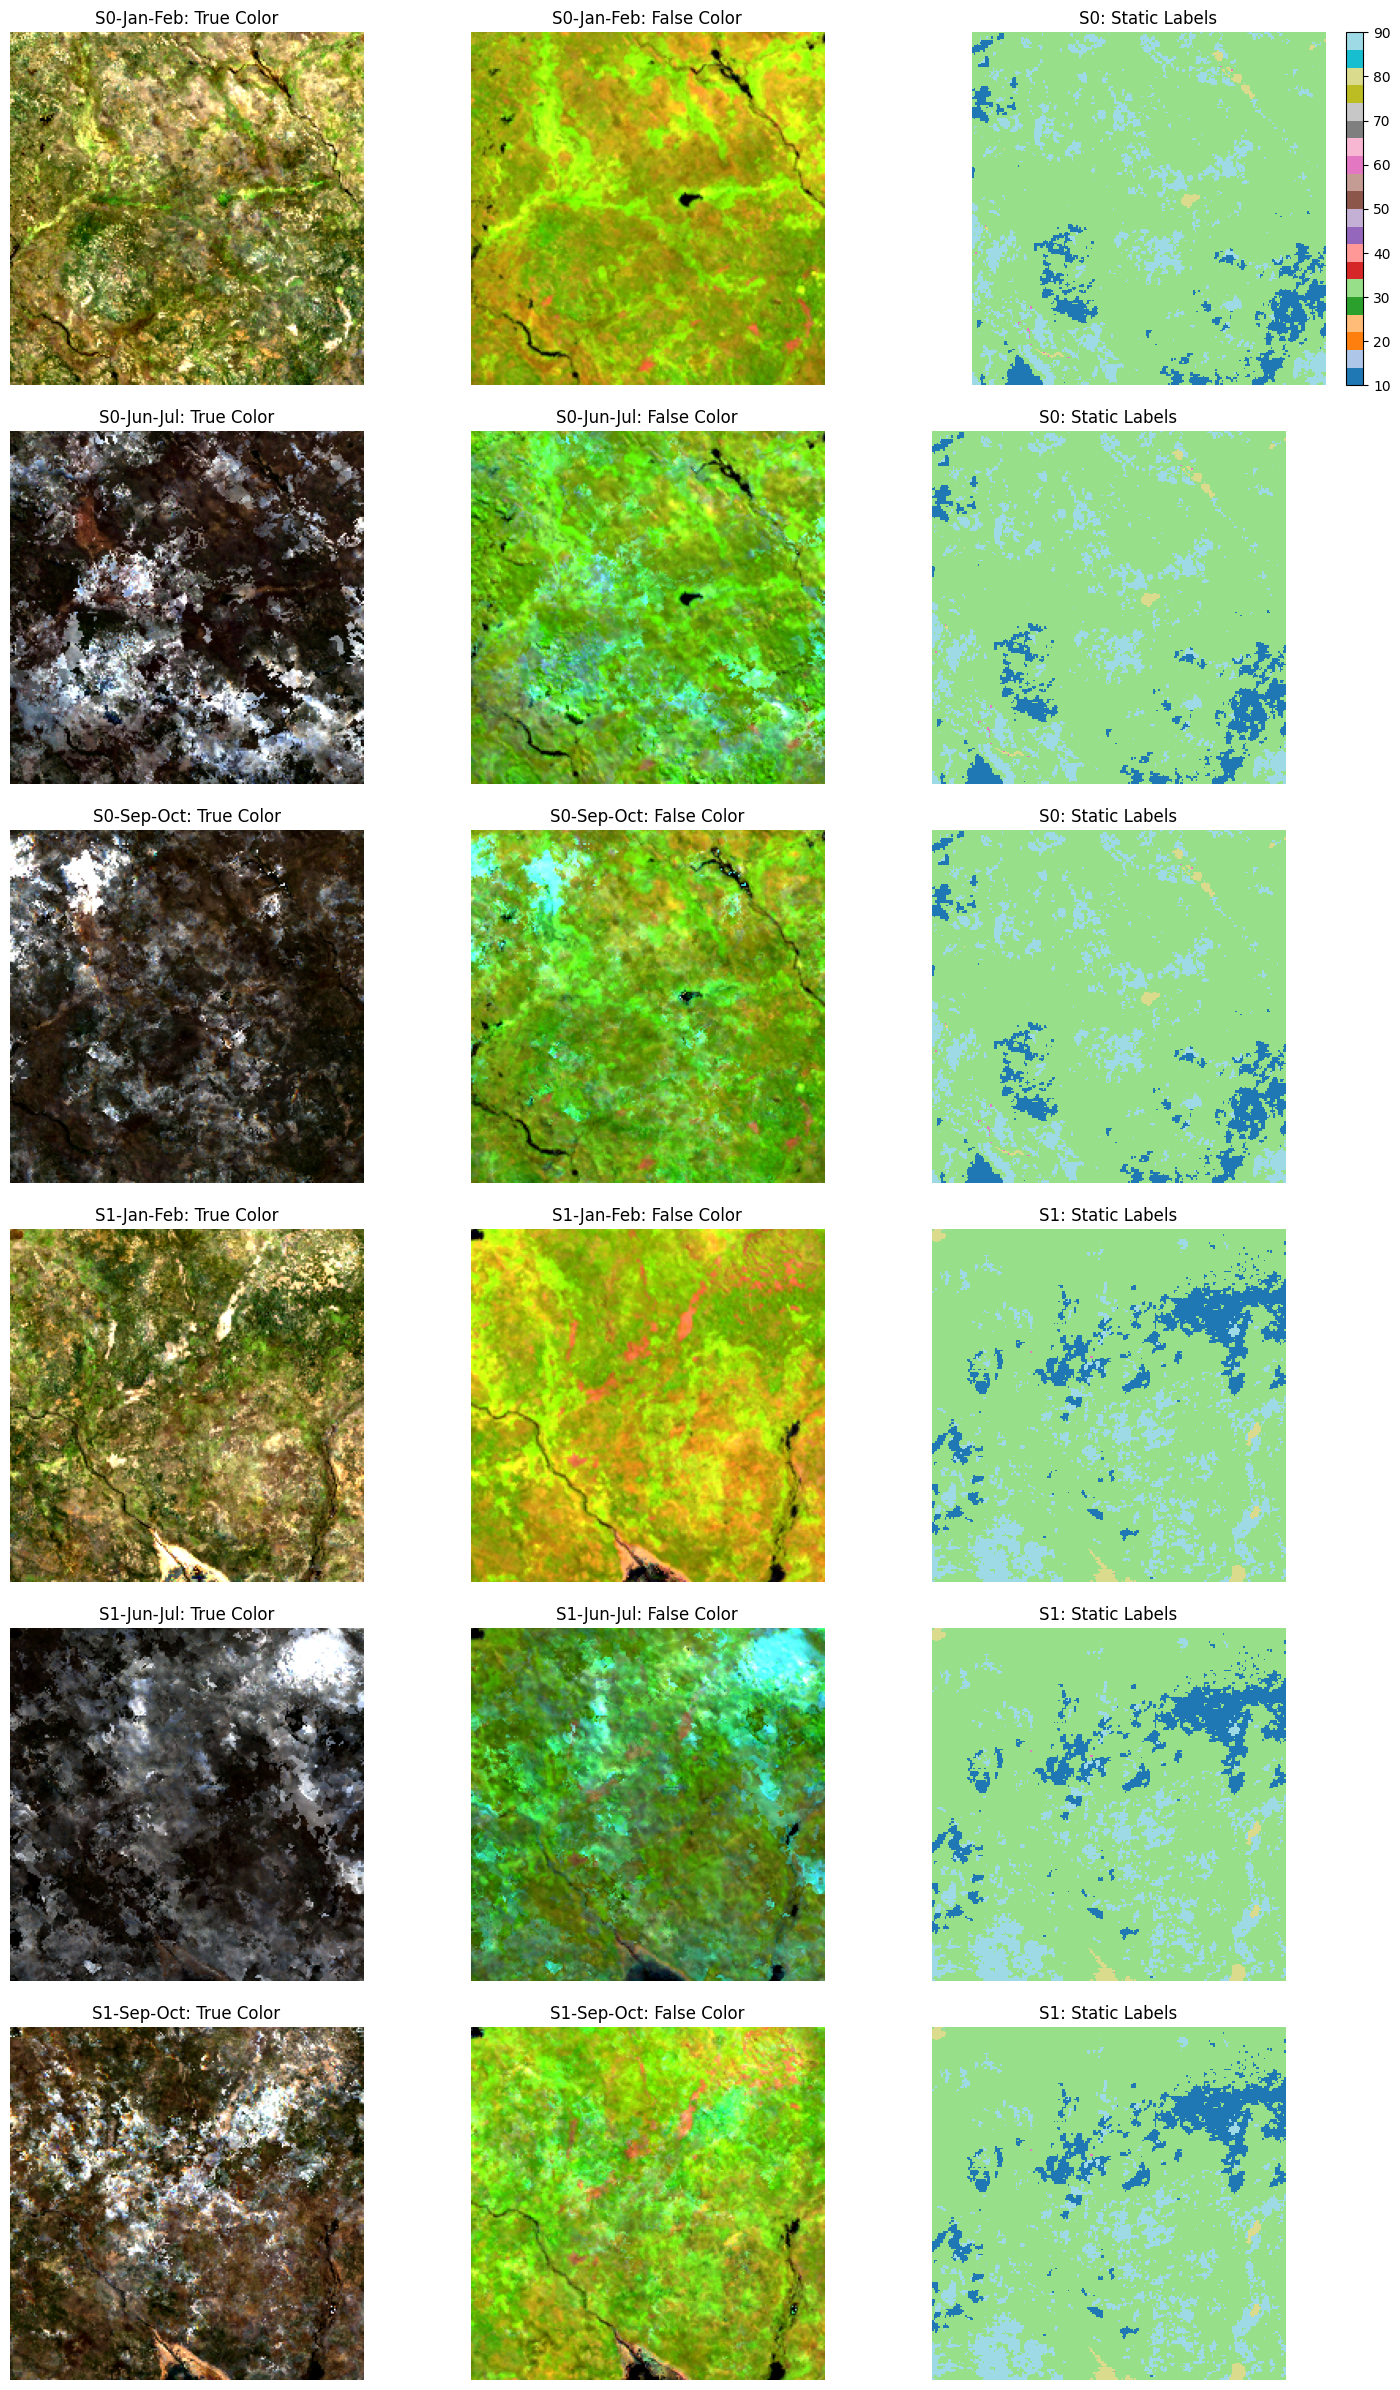

In [8]:


ds = verify_s3_zarr_dataset(
    bucket=bucket,
    userid=userid,
    project_name=project_name,
    dataset_name="training_dataset_v3.zarr",
    max_samples=2,
    make_plots=True,
)


The next notebook, 7b willshow how this process can be more efficient using `ice-chunk`. This is the method I reccomend.

# Be a good Dask user and close your cluster when you are done

In [9]:
client.close()
cluster.shutdown()